<a href="https://colab.research.google.com/github/AchyuthaAshish/AI-ML-Projects/blob/main/04_Plant_Disease_Detection/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries

!pip -q install tensorflow scikit-learn matplotlib seaborn

In [2]:
# Cell 2 — Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("✅ All imports completed successfully!")

TensorFlow version: 2.21.0
NumPy version: 2.5.3
GPU available: True
✅ All imports completed successfully!


In [3]:
# Cell 3 — Install TensorFlow Datasets

!pip -q install tensorflow-datasets

In [4]:
!pip -q install -U datasets

Loading PlantVillage dataset from Hugging Face...


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 31.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1900 [00:00<?, ? examples/s]


✅ Dataset loaded successfully!
Total images: 1900
Number of disease classes: 38

First 10 classes:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


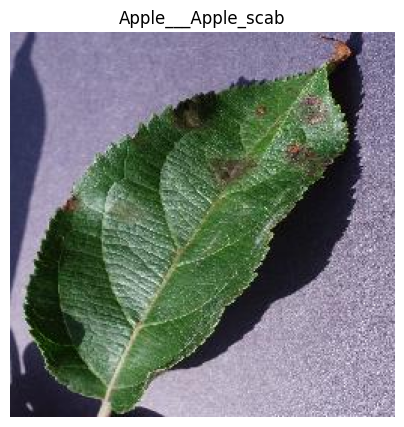

In [5]:
from datasets import load_dataset
import matplotlib.pyplot as plt

print("Loading PlantVillage dataset from Hugging Face...")

plant_dataset = load_dataset(
    "geraldmc/plantvillage-tiny",
    revision="v0.1.0",
    split="train"
)

class_names = sorted(set(plant_dataset["class_label"]))
num_classes = len(class_names)

print("\n✅ Dataset loaded successfully!")
print("Total images:", len(plant_dataset))
print("Number of disease classes:", num_classes)
print("\nFirst 10 classes:")
print(class_names[:10])

# Display a sample image
sample = plant_dataset[0]
plt.figure(figsize=(5, 5))
plt.imshow(sample["image"])
plt.title(sample["class_label"])
plt.axis("off")
plt.show()

In [6]:
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("Preprocessing plant leaf images...")

IMG_SIZE = 128

# Convert images to RGB and resize them
X = np.array([
    np.array(img.convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    for img in plant_dataset["image"]
], dtype=np.uint8)

# Encode disease class names as numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(plant_dataset["class_label"])

class_names = label_encoder.classes_
num_classes = len(class_names)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n✅ Image preprocessing completed!")
print("Image shape:", X.shape)
print("Number of classes:", num_classes)
print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)
print("\nDisease classes:", list(class_names))

Preprocessing plant leaf images...

✅ Image preprocessing completed!
Image shape: (1900, 128, 128, 3)
Number of classes: 38
Training images: 1520
Validation images: 380
Training labels shape: (1520,)
Validation labels shape: (380,)

Disease classes: [np.str_('Apple___Apple_scab'), np.str_('Apple___Black_rot'), np.str_('Apple___Cedar_apple_rust'), np.str_('Apple___healthy'), np.str_('Blueberry___healthy'), np.str_('Cherry_(including_sour)___Powdery_mildew'), np.str_('Cherry_(including_sour)___healthy'), np.str_('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'), np.str_('Corn_(maize)___Common_rust_'), np.str_('Corn_(maize)___Northern_Leaf_Blight'), np.str_('Corn_(maize)___healthy'), np.str_('Grape___Black_rot'), np.str_('Grape___Esca_(Black_Measles)'), np.str_('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'), np.str_('Grape___healthy'), np.str_('Orange___Haunglongbing_(Citrus_greening)'), np.str_('Peach___Bacterial_spot'), np.str_('Peach___healthy'), np.str_('Pepper,_bell___Bacterial_sp

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling
)

model = Sequential([
    Input(shape=(128, 128, 3)),

    # Normalize pixel values from 0–255 to 0–1
    Rescaling(1./255),

    # First convolution block
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Second convolution block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Third convolution block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Classification layers
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ CNN model created successfully!\n")
model.summary()

✅ CNN model created successfully!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if validation loss does not improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Starting CNN training...")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ CNN training completed!")

Starting CNN training...
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.0467 - loss: 3.6291 - val_accuracy: 0.0947 - val_loss: 3.4464 - learning_rate: 0.0010
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1296 - loss: 3.3119 - val_accuracy: 0.2263 - val_loss: 3.0853 - learning_rate: 0.0010
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2362 - loss: 2.8255 - val_accuracy: 0.3105 - val_loss: 2.6794 - learning_rate: 0.0010
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3500 - loss: 2.3100 - val_accuracy: 0.3842 - val_loss: 2.2824 - learning_rate: 0.0010
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4789 - loss: 1.7836 - val_accuracy: 0.3737 - val_loss: 2.3062 - learning_rate: 0.0010
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5533 - loss: 1.4524 - val_accuracy: 0.4711 - val_loss: 1.9956 - learning_rate: 0.0010
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.63

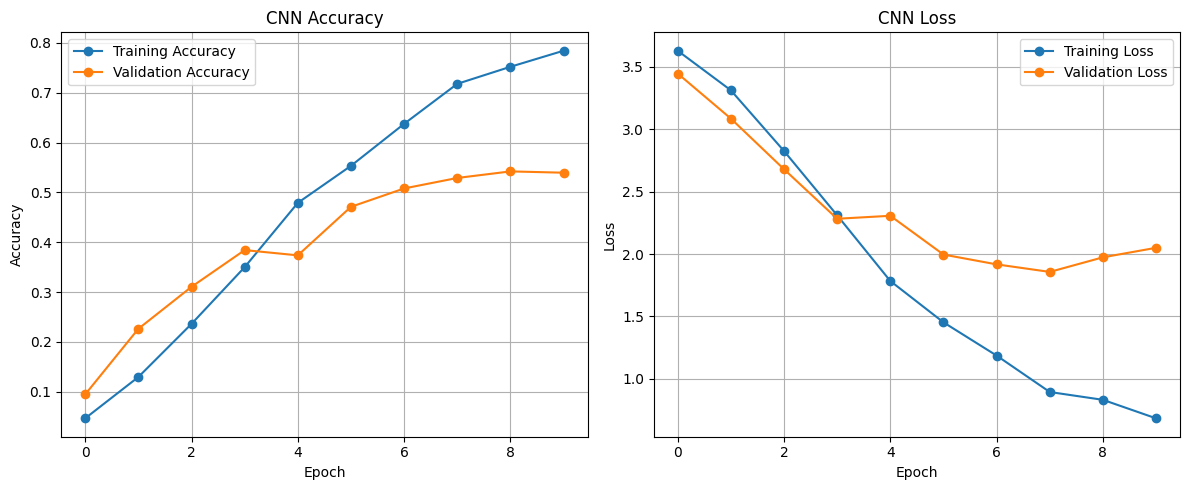

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Evaluate the best restored model
val_loss, val_accuracy = model.evaluate(
    X_val, y_val, verbose=0
)

# Generate predictions
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(
    classification_report(
        y_val,
        y_pred,
        labels=np.arange(num_classes),
        target_names=[str(name) for name in class_names],
        zero_division=0
    )
)

Validation Loss: 1.8565
Validation Accuracy: 52.89%

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.12      0.10      0.11        10
                                 Apple___Black_rot       0.78      0.70      0.74        10
                          Apple___Cedar_apple_rust       0.33      0.40      0.36        10
                                   Apple___healthy       0.50      0.60      0.55        10
                               Blueberry___healthy       0.43      0.60      0.50        10
          Cherry_(including_sour)___Powdery_mildew       0.60      0.30      0.40        10
                 Cherry_(including_sour)___healthy       0.43      0.30      0.35        10
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.47      0.70      0.56        10
                       Corn_(maize)___Common_rust_       0.67      1.00      0.80        10
  

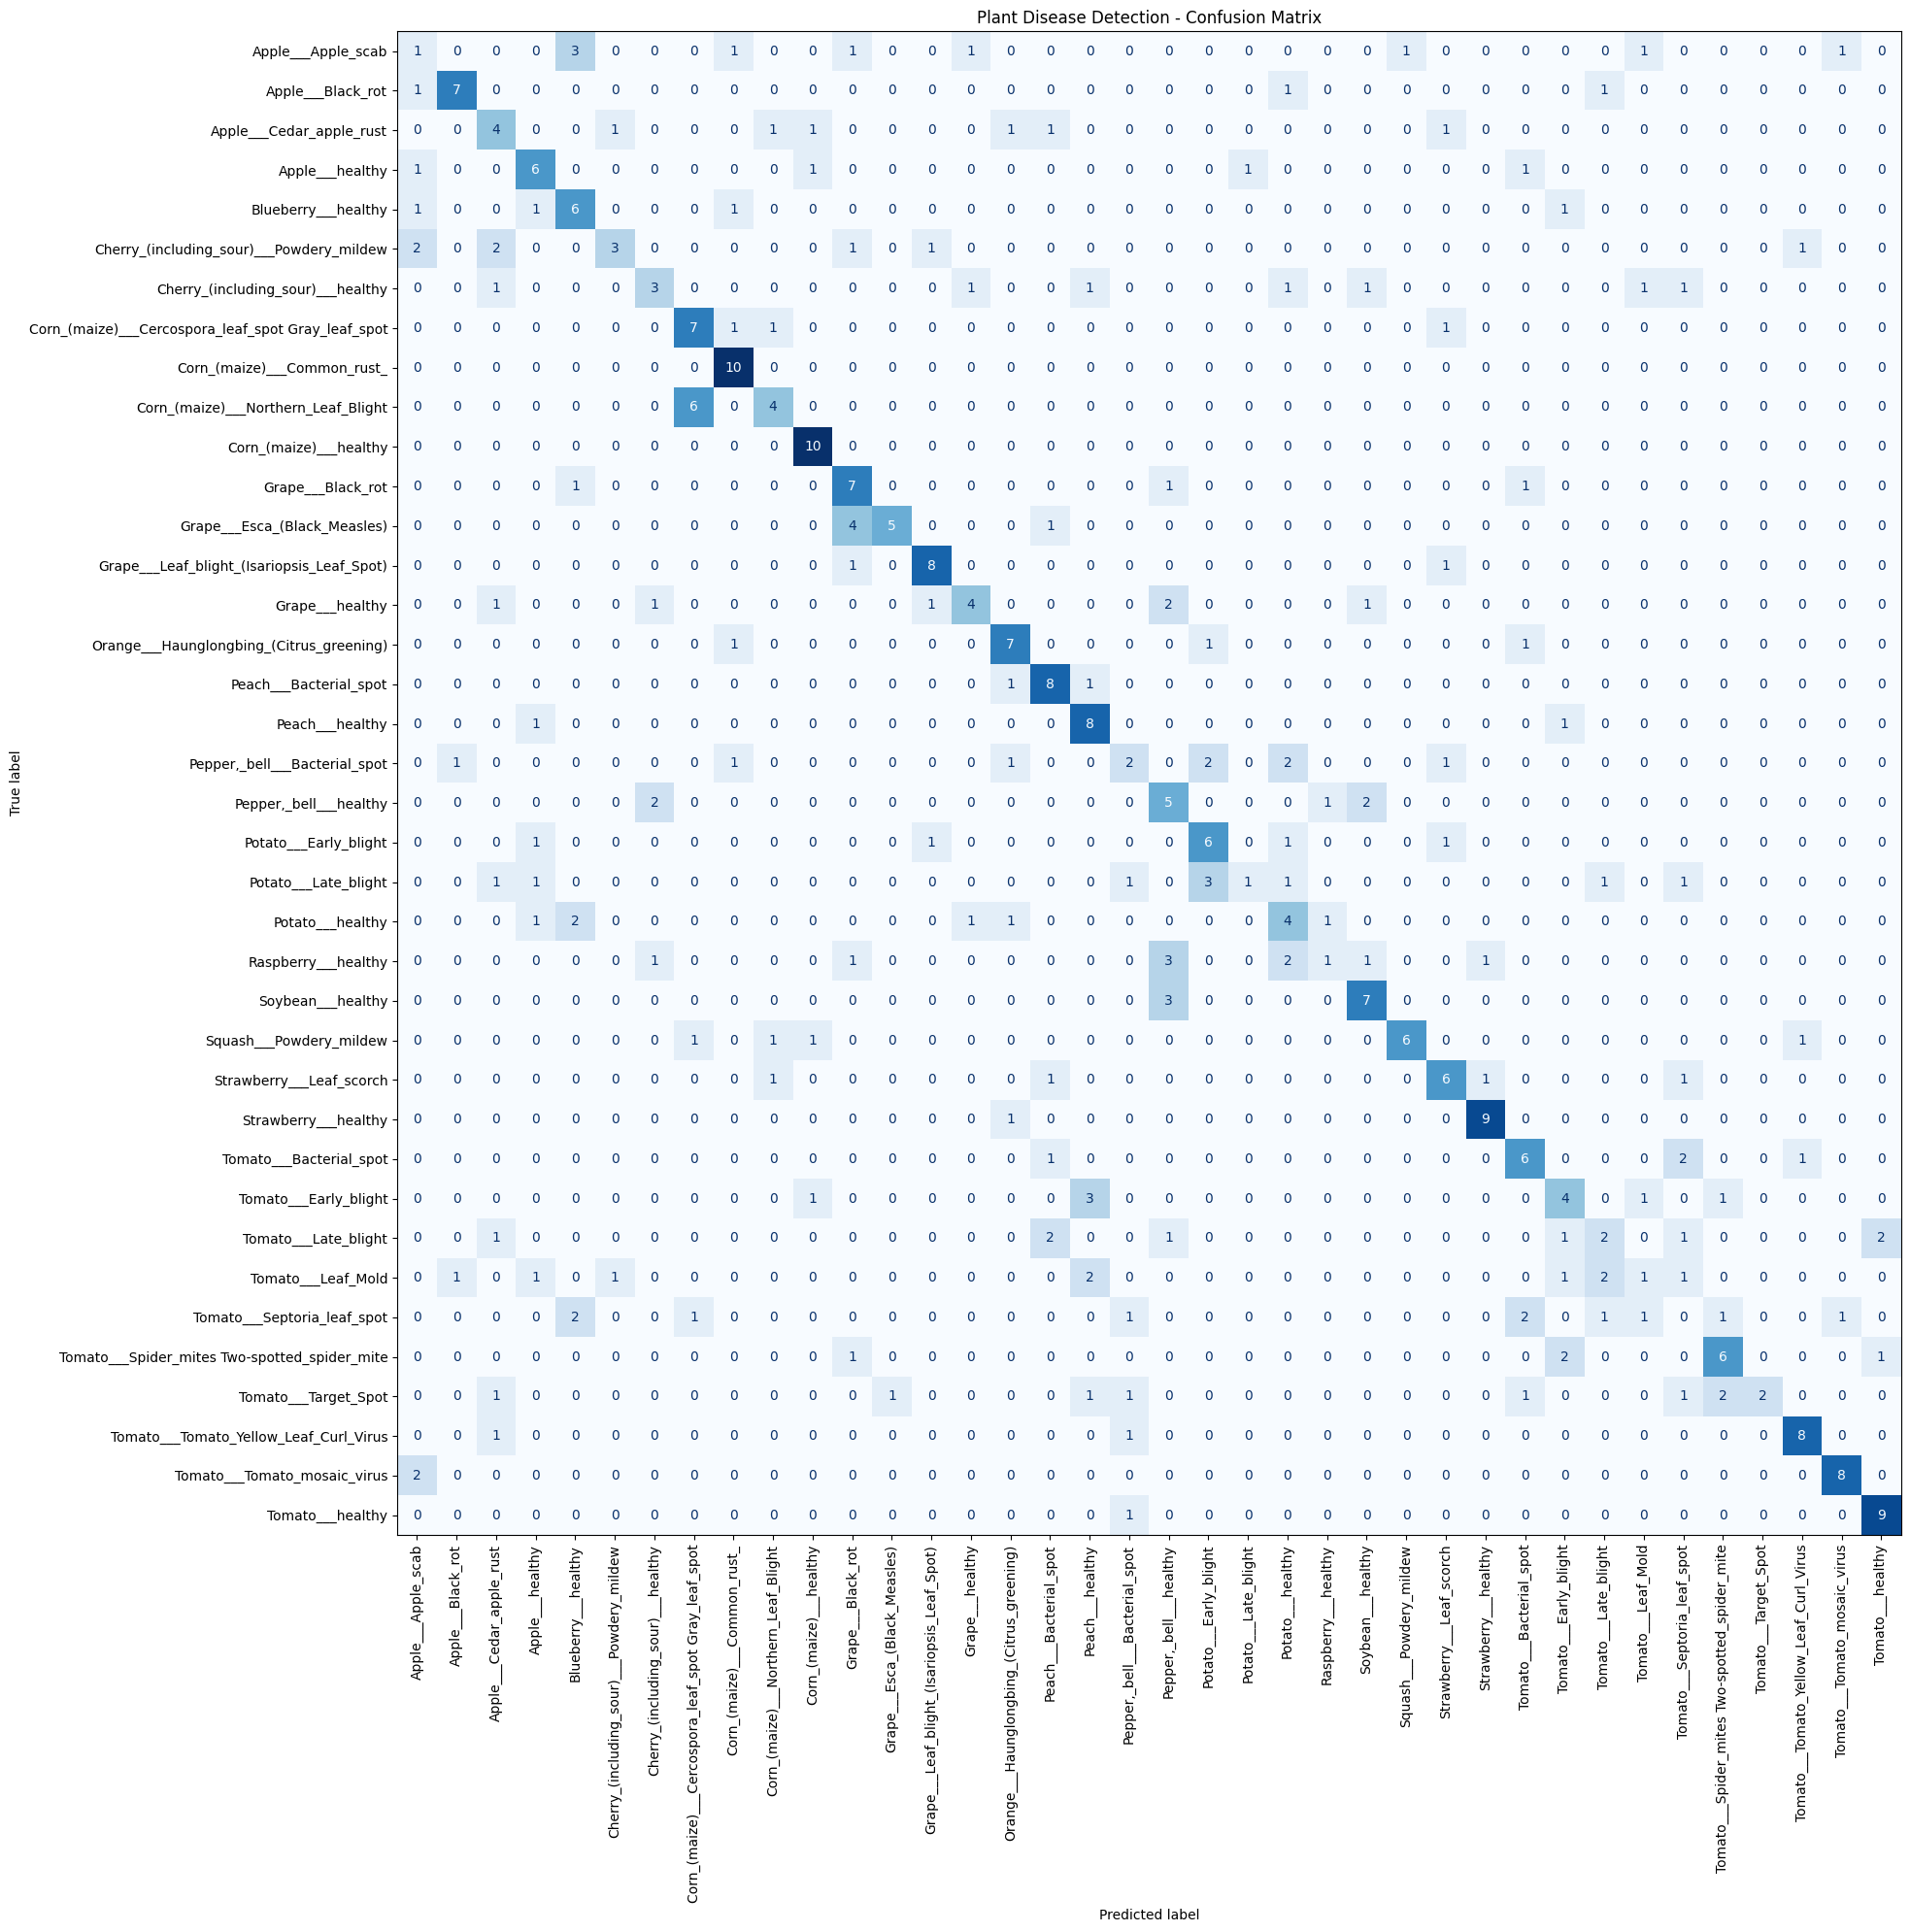

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=np.arange(num_classes)
)

plt.figure(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[str(name) for name in class_names]
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation="vertical",
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

plt.title("Plant Disease Detection - Confusion Matrix")
plt.tight_layout()
plt.show()

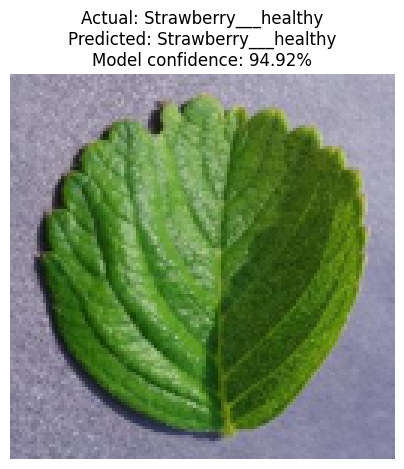

Actual class:    Strawberry___healthy
Predicted class: Strawberry___healthy
Model confidence: 94.92%
Prediction correct: True


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Select one validation image
index = 0

image = X_val[index]
actual_label = int(y_val[index])

# Predict its class
probabilities = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)[0]

predicted_label = int(np.argmax(probabilities))
confidence = float(probabilities[predicted_label]) * 100

# Display the image and prediction
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"Predicted: {class_names[predicted_label]}\n"
    f"Model confidence: {confidence:.2f}%"
)
plt.show()

print("Actual class:   ", class_names[actual_label])
print("Predicted class:", class_names[predicted_label])
print(f"Model confidence: {confidence:.2f}%")
print(
    "Prediction correct:",
    predicted_label == actual_label
)

Saving images (1).jpg to images (1) (1).jpg
Saving images.jpg to images (3).jpg


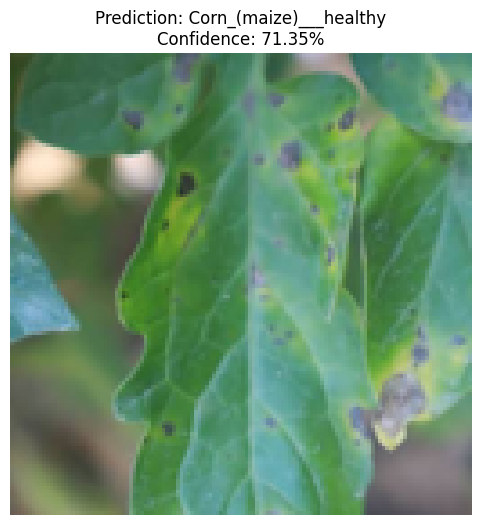

Uploaded image: images (1) (1).jpg
Predicted class: Corn_(maize)___healthy
Model confidence: 71.35%


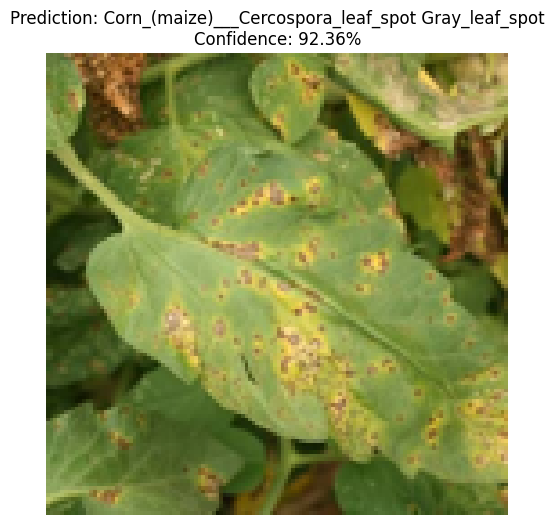

Uploaded image: images (3).jpg
Predicted class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Model confidence: 92.36%


In [18]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload a leaf image
uploaded = files.upload()

for filename in uploaded.keys():
    # Open and preprocess the image
    image = Image.open(filename).convert("RGB")
    image = image.resize((128, 128))

    image_array = np.array(image, dtype=np.uint8)

    # Predict the class
    probabilities = model.predict(
        np.expand_dims(image_array, axis=0),
        verbose=0
    )[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_class = str(class_names[predicted_index])
    confidence = float(probabilities[predicted_index]) * 100

    # Display the uploaded image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("Uploaded image:", filename)
    print("Predicted class:", predicted_class)
    print(f"Model confidence: {confidence:.2f}%")

In [14]:
import os
import json

# Create a folder for saved model files
os.makedirs("plant_disease_model", exist_ok=True)

# Save the trained model
model.save("plant_disease_model/plant_disease_cnn.keras")

# Save the class labels in the correct order
with open("plant_disease_model/class_names.json", "w") as file:
    json.dump([str(name) for name in class_names], file, indent=4)

print("✅ Model and class labels saved successfully!")
print("\nSaved files:")
print("- plant_disease_model/plant_disease_cnn.keras")
print("- plant_disease_model/class_names.json")

✅ Model and class labels saved successfully!

Saved files:
- plant_disease_model/plant_disease_cnn.keras
- plant_disease_model/class_names.json


In [15]:
import tensorflow as tf
import numpy as np
import json

# Load the saved model
loaded_model = tf.keras.models.load_model(
    "plant_disease_model/plant_disease_cnn.keras"
)

# Load class labels
with open("plant_disease_model/class_names.json", "r") as file:
    saved_class_names = json.load(file)

# Test a validation image
test_image = X_val[0]

original_prediction = int(
    np.argmax(model.predict(test_image[None, ...], verbose=0)[0])
)

saved_prediction = int(
    np.argmax(loaded_model.predict(test_image[None, ...], verbose=0)[0])
)

print("Original model prediction:", str(class_names[original_prediction]))
print("Loaded model prediction:  ", saved_class_names[saved_prediction])
print("Predictions match:", original_prediction == saved_prediction)

assert original_prediction == saved_prediction
assert saved_class_names == [str(name) for name in class_names]

print("\n✅ Saved model verified successfully!")

Original model prediction: Strawberry___healthy
Loaded model prediction:   Strawberry___healthy
Predictions match: True

✅ Saved model verified successfully!


In [16]:
import shutil
from google.colab import files

shutil.make_archive(
    "plant_disease_model",
    "zip",
    root_dir="plant_disease_model"
)

files.download("plant_disease_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>